# Bias Variance

- This notebook estimates bias and variance by learning repeatedly from
  random training sets, on the target function $f(x) = \sin(\pi x)$, to show
  how the expected error splits into two parts
- The pedagogical arc:
  - Approximation vs learning: the best constant and linear models, then one
    learned model
  - The bias-variance decomposition, and how it changes with the training set
    size
  - The same decomposition when the observations are noisy

In [79]:
%load_ext autoreload
%autoreload 2

import logging

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
import helpers.hintrospection as hintros
import helpers.hnotebook as hnotebook

import L05_02_01_bias_variance_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

# Part 1: Approximation vs Learning

## Cell 1.1: Approximation

**Goal**
- Compare how well a constant model and a linear model can approximate
  the true target function $f(x) = \sin(\pi x)$ on $x \in [-1, 1]$, with
  no notion of training data yet

**Implementation** `cell1_approximation()`
- Fits $g_0(x) = b$ and $g_1(x) = ax + b$ directly to the dense true
  function by least squares, in `fit_constant_model()`/`fit_linear_model()`
- Plots `True function vs constant model` and `True function vs linear
  model`, each shading the approximation error, plus a `Comments` panel
  with both models' equations and errors

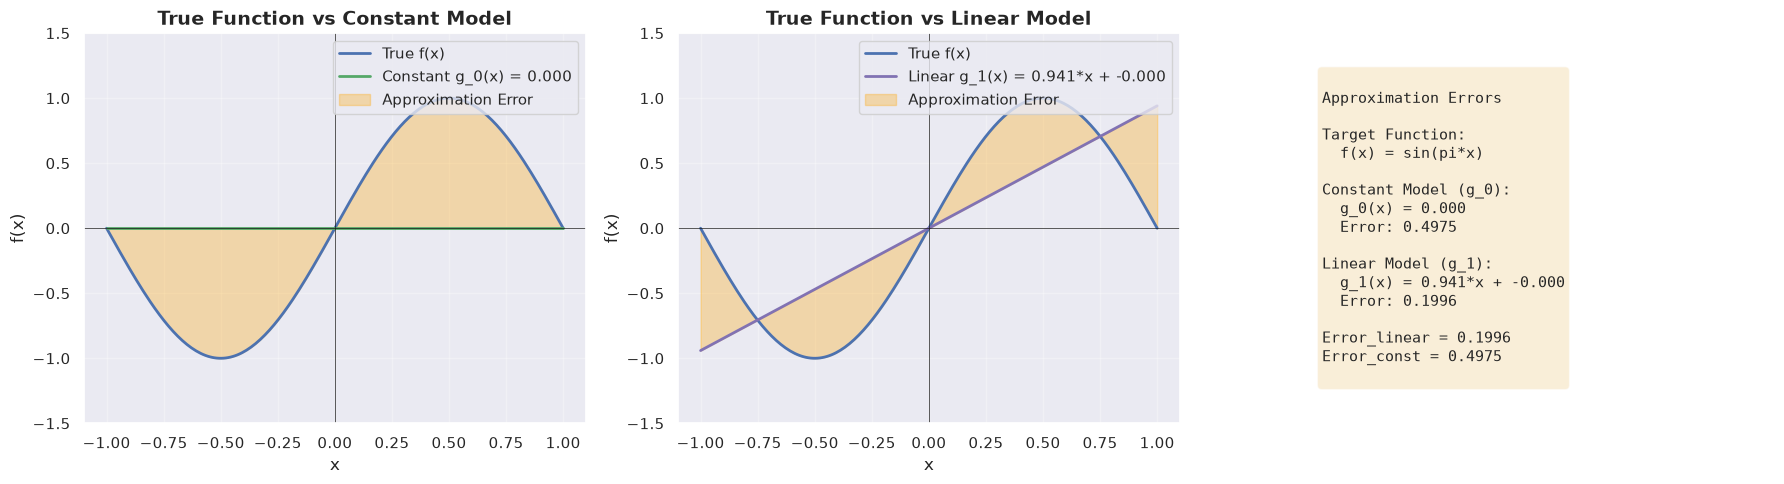

In [81]:
# Display approximation comparison between constant and linear models.
utils.cell1_approximation()

## Cell 1.2: Learning once

**Goal**
- Contrast learning from a small training set with the pure
  approximation of Cell 1.1, and separate in-sample error $E_{in}$ from
  out-of-sample error $E_{out}$

**Description**
- Inputs
  - `seed`: random seed for the training points sampled
  - `N_samples`: number of training points, 2-20

- Panels
  - `Constant model`: $f(x)$, the fitted $g_0$, and the training
    points, titled with $E_{in}$/$E_{out}$
  - `Linear model`: $f(x)$, the fitted $g_1$, and the training
    points, titled with $E_{in}$/$E_{out}$
  - `Comments`: current `seed`, `N_samples`, and both models'
    $E_{in}$/$E_{out}$

In [82]:
# Display learning from N random samples with interactive controls.
utils.cell2_learning_once()

Output()

**Guided usage**
- Leave `N_samples` at 2 and change `seed` a few times
  - Observe the linear model reaches $E_{in} = 0$ on almost every draw
    (2 points fully determine a line), yet $E_{out}$ still varies widely
- Raise `N_samples` from 2 toward 20
  - Observe $E_{in}$ for the linear model rise off zero, while $E_{out}$
    for both models settles down: fitting 2 points perfectly is not the
    same as learning $f$

**Implementation** `cell2_learning_once()`
- Draws `N_samples` random training points and fits $g_0$/$g_1$ to them
  with `fit_models_and_predict()`
- Computes $E_{in}$ (error on the training points) and $E_{out}$ (error
  against the true function) for both models

In [83]:
hintros.print_obj_info(utils.cell2_learning_once)

- `cell2_learning_once() -> None`  
  Show learning from N random samples is different from approximation.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/msml610/tutorials/L05_statistical_learning/L05_02_01_bias_variance_utils.py#L1


# Part 2: Bias-Variance Decomposition

## Cell 2.1: Learning: bias-variance decomposition

**Goal**
- Repeat Cell 1.2's experiment across many random training sets, and
  read bias and variance off how the resulting models scatter around $f$

**Description**
- Inputs
  - `seed`: random seed for the experiments
  - `N_samples`: training points per experiment, 2-20
  - `N_experiments`: number of repeated experiments, 5-100

- Panels
  - `Constant models`: $f(x)$, every fitted $g_0$, and their average
  - `Linear models`: $f(x)$, every fitted $g_1$, and their average
  - `Comments`: average $E_{in}$/$E_{out}$ and the bias-variance
    reading for both models

In [84]:
# Display bias-variance decomposition over multiple experiments.
utils.cell3_learning_bias_variance()

Output()

**Guided usage**
- Compare the two panels at the default `N_samples = 2`
  - Observe the constant lines cluster tightly (low variance) but sit
    far from $f$ (high bias), while the linear lines spread widely
    (higher variance) but average closer to $f$ (lower bias)
- Raise `N_experiments` toward 100
  - Observe the average line in each panel stabilize, giving a more
    reliable bias estimate without changing how spread out the
    individual fits are

**Implementation** `cell3_learning_bias_variance()`
- Runs `N_experiments` independent draws of `N_samples` points, refitting
  $g_0$ and $g_1$ each time
- Overlays every fitted model in translucent lines, plus the average
  model as a dashed line, so bias (average vs $f$) and variance (spread
  around the average) are both visible at once

In [85]:
hintros.print_obj_info(utils.cell3_learning_bias_variance)

- `cell3_learning_bias_variance() -> None`  
  Visualize bias-variance decomposition over multiple experiments.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/msml610/tutorials/L05_statistical_learning/L05_02_01_bias_variance_utils.py#L1


## Cell 2.2: Learning plots: bias-variance vs training set size

**Goal**
- Trace how $E_{in}$, $E_{out}$, $\text{bias}^2$, and variance move as
  training set size grows, for both models at once

**Description**
- Inputs
  - `seed`: random seed, fixed across training sizes for a fair
    comparison
  - `N_experiments`: experiments averaged per training size, 20-200
  - `max_N_samples`: largest training size swept, 5-30

- Panels
  - `Constant model (g_0), bias-variance analysis`: $E_{in}$,
    $E_{out}$, $\text{Bias}^2$, and variance vs training size
  - `Linear model (g_1), bias-variance analysis`: the same four
    curves for $g_1$
  - `Comments`: the decomposition formula and both models' values
    at `max_N_samples`

In [86]:
# Display bias-variance decomposition as a function of N_samples.
utils.cell4_learning_plots()

Output()

**Guided usage**
- Raise `max_N_samples` toward 30
  - Observe variance keep shrinking toward 0 for both models, while
    each model's bias curve flattens out at its own level
- Compare the flattened bias level between panels
  - Observe the linear model's bias floor sits below the constant
    model's: more model capacity lowers bias, at the cost of the
    variance seen in Cell 2.1

**Implementation** `cell4_learning_plots()`
- Repeats Cell 2.1's experiment at every training size from 2 up to
  `max_N_samples`, averaging `N_experiments` trials at each size
- Plots the four error curves for $g_0$ and $g_1$ side by side, verifying
  $E_{out} \approx \text{Bias}^2 + \text{Variance}$ for this noise-free
  target

In [87]:
hintros.print_obj_info(utils.cell4_learning_plots)

- `cell4_learning_plots() -> None`  
  Compute and visualize bias-variance decomposition as a function of N_samples.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/msml610/tutorials/L05_statistical_learning/L05_02_01_bias_variance_utils.py#L742


# Part 3: Bias-Variance With Noise

## Cell 3.0: Learning once with noise

**Goal**
- Contrast learning from a small training set with noisy labels, and see
  how noise affects in-sample and out-of-sample error

**Description**
- Inputs
  - `seed`: random seed for the training points sampled
  - `N_samples`: number of training points, 2-20
  - `noise_std`: standard deviation $\sigma$ of the label noise, 0-0.5

- Panels
  - `Constant model`: $f(x)$, the fitted $g_0$, and the training
    points, titled with $E_{in}$/$E_{out}$
  - `Linear model`: $f(x)$, the fitted $g_1$, and the training
    points, titled with $E_{in}$/$E_{out}$
  - `Comments`: current `seed`, `N_samples`, noise std, and both models'
    $E_{in}$/$E_{out}$

In [88]:
# Display learning from N random samples with noise and interactive controls.
utils.cell2_learning_once_with_noise()

Output()

**Implementation** `cell2_learning_once_with_noise()`
- Draws `N_samples` random training points with Gaussian noise and fits
  $g_0$/$g_1$ to them with `fit_models_and_predict()`
- Computes $E_{in}$ and $E_{out}$ for both models, demonstrating how noise
  inflates both errors

## Cell 3.1: Learning with noise: bias-variance decomposition

**Goal**
- Repeat Cell 2.1's multi-experiment view with Gaussian noise added to
  the training labels, $y = f(x) + \mathcal{N}(0, \sigma^2)$

**Description**
- Inputs
  - `seed`: random seed for the experiments
  - `noise_std`: standard deviation $\sigma$ of the label noise,
    0-0.5
  - `N_samples`: training points per experiment, 2-20
  - `N_experiments`: number of repeated experiments, 5-100

- Panels
  - `Constant models`: $f(x)$, every fitted $g_0$, and their average
  - `Linear models`: $f(x)$, every fitted $g_1$, and their average
  - `Comments`: average $E_{in}$/$E_{out}$ for both models at the
    current noise level

In [89]:
# Display bias-variance decomposition with noise over multiple experiments.
utils.cell5_learning_with_noise()

Output()

**Guided usage**
- Leave `noise_std` at 0 and compare against Cell 2.1
  - Observe the two panels match Cell 2.1 exactly: zero noise recovers
    the noise-free case
- Raise `noise_std` from 0 toward 0.5
  - Observe both panels spread out further and $E_{out}$ climb for both
    models, since every fit now chases noise the true function never had

**Implementation** `cell5_learning_with_noise()`
- Adds noise of standard deviation `noise_std` to each training draw
  before fitting $g_0$/$g_1$, otherwise identical to
  `cell3_learning_bias_variance()`

In [90]:
hintros.print_obj_info(utils.cell5_learning_with_noise)

- `cell5_learning_with_noise() -> None`  
  Visualize bias-variance decomposition with noise over multiple experiments.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/msml610/tutorials/L05_statistical_learning/L05_02_01_bias_variance_utils.py#L944


## Cell 3.2: Learning plots with noise: bias-variance vs training set size

**Goal**
- Trace $E_{in}$, $E_{out}$, $\text{bias}^2$, and variance against
  training set size, as in Cell 2.2, now with noisy training labels

**Description**
- Inputs
  - `seed`: random seed, fixed across training sizes
  - `noise_std`: standard deviation $\sigma$ of the label noise,
    0-0.5
  - `log(N_samples)` (log scale): largest training size swept, 2-256
  - `log(N_experiments)` (log scale): experiments averaged per
    training size, 16-1024

- Panels
  - `Constant model (g_0), bias-variance analysis`: $E_{in}$,
    $E_{out}$, $\text{Bias}^2$, and variance vs training size
  - `Linear model (g_1), bias-variance analysis`: the same four
    curves for $g_1$
  - `Comments`: the noisy decomposition formula and both models'
    values at the largest training size

In [91]:
# Display bias-variance decomposition with noise as a function of N_samples.
utils.cell6_learning_plots_with_noise()

Output()

**Guided usage**
- Set `noise_std` to 0.1 or 0.2 and compare against Cell 2.2
  - Observe both $E_{out}$ curves shift up by roughly $\sigma^2$, while
    the bias curves barely move: noise adds an irreducible floor, it
    does not change what the model class can represent
- Raise `log(N_samples)` toward its maximum with noise still on
  - Observe variance keeps shrinking as before, but $E_{out}$ levels off
    above 0: more data cannot remove the noise term, only the variance
    term

**Implementation** `cell6_learning_plots_with_noise()`
- Repeats Cell 2.2's sweep with `noise_std` added to every training draw
  before fitting, over `N_samples` from 2 up to the current slider value

In [92]:
hintros.print_obj_info(utils.cell6_learning_plots_with_noise)

- `cell6_learning_plots_with_noise() -> None`  
  Compute and visualize bias-variance decomposition with noise as a function of N_samples.

https://github.com/gpsaggese/gpsaggese.github.io/blob/gp/msml610/tutorials/L05_statistical_learning/L05_02_01_bias_variance_utils.py#L1212
